Question 1

In [2]:
!pip install scikit-learn-extra
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import adjusted_rand_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 17.4 MB/s eta 0:00:00


In [3]:
# Set seed for reproducibility
np.random.seed(42)

# Generate three clusters with given means and diagonal covariance matrix
means = np.array([[0, 0, 0, 0, 0], [5, 5, 5, 5, 5], [11, 11, 11, 11, 11]])
covariance = np.diag([2] * 5)  # Diagonal covariance matrix with variance 2

# Generate 40 points per cluster
data = np.vstack([np.random.multivariate_normal(mean, covariance, 40) for mean in means])
labels_true_120 = np.repeat([0, 1, 2], 40)  # True cluster labels

# Add three outliers
outliers = np.array([[-12, 5, 0, 0, 0], [100, 11, 11, 5, 5], [-100, 0, 0, 0, -100]])
data_outliers = np.vstack([data, outliers])
labels_true_123 = np.append(labels_true_120, [-1, -1, -1])  # Assign outliers label -1

a)

In [4]:
def squared_euclidean_distance(a, b):
    return np.sum((a - b) ** 2, axis=1)

def manhattan_distance(a, b):
    return np.sum(np.abs(a - b), axis=1)

def kmeans_lloyd(data, k, max_iters=100, tol=1e-4):
    np.random.seed(42)
    centroids = data[np.random.choice(len(data), k, replace=False)]
    for _ in range(max_iters):
        labels = np.argmin([squared_euclidean_distance(data, centroid) for centroid in centroids], axis=0)
        new_centroids = np.array([data[labels == i].mean(axis=0) for i in range(k)])
        if np.linalg.norm(new_centroids - centroids) < tol:
            break
        centroids = new_centroids
    total_cost = sum(np.min([squared_euclidean_distance(data, centroid) for centroid in centroids], axis=0))
    return labels, centroids, total_cost

def kmedoids_lloyd(data, k, max_iters=100):
    np.random.seed(42)
    medoids = data[np.random.choice(len(data), k, replace=False)]
    for _ in range(max_iters):
        labels = np.argmin([manhattan_distance(data, medoid) for medoid in medoids], axis=0)
        new_medoids = np.array([data[labels == i][np.argmin(np.sum(manhattan_distance(data[labels == i], data[labels == i][:, np.newaxis]), axis=1))] for i in range(k)])
        if np.array_equal(new_medoids, medoids):
            break
        medoids = new_medoids
    total_cost = sum(np.min([manhattan_distance(data, medoid) for medoid in medoids], axis=0))
    return labels, medoids, total_cost

# Perform clustering on 120-point dataset
kmeans_labels_120, kmeans_centroids_120, kmeans_cost_120 = kmeans_lloyd(data, 3)
kmedoids_labels_120, kmedoids_medoids_120, kmedoids_cost_120 = kmedoids_lloyd(data, 3)

# Perform clustering on 123-point dataset
kmeans_labels_123, kmeans_centroids_123, kmeans_cost_123 = kmeans_lloyd(data_outliers, 3)
kmedoids_labels_123, kmedoids_medoids_123, kmedoids_cost_123 = kmedoids_lloyd(data_outliers, 3)

# Evaluate clustering performance (excluding outliers)
mask = labels_true_123 != -1
ari_kmeans_120 = adjusted_rand_score(labels_true_120, kmeans_labels_120)
ari_kmedoids_120 = adjusted_rand_score(labels_true_120, kmedoids_labels_120)
ari_kmeans_123 = adjusted_rand_score(labels_true_123[mask], kmeans_labels_123[mask])
ari_kmedoids_123 = adjusted_rand_score(labels_true_123[mask], kmedoids_labels_123[mask])

print("--- 120-point dataset ---")
print(f"Adjusted Rand Index (K-Means Lloyd): {ari_kmeans_120:.4f}")
print(f"Adjusted Rand Index (K-Medoids Lloyd): {ari_kmedoids_120:.4f}")
print(f"Total Cost (K-Means): {kmeans_cost_120:.4f}")
print(f"Total Cost (K-Medoids): {kmedoids_cost_120:.4f}")

print("\n--- 123-point dataset with outliers ---")
print(f"Adjusted Rand Index (K-Means Lloyd): {ari_kmeans_123:.4f}")
print(f"Adjusted Rand Index (K-Medoids Lloyd): {ari_kmedoids_123:.4f}")
print(f"Total Cost (K-Means): {kmeans_cost_123:.4f}")
print(f"Total Cost (K-Medoids): {kmedoids_cost_123:.4f}")

--- 120-point dataset ---
Adjusted Rand Index (K-Means Lloyd): 1.0000
Adjusted Rand Index (K-Medoids Lloyd): 1.0000
Total Cost (K-Means): 1094.8057
Total Cost (K-Medoids): 679.4044

--- 123-point dataset with outliers ---
Adjusted Rand Index (K-Means Lloyd): 1.0000
Adjusted Rand Index (K-Medoids Lloyd): 1.0000
Total Cost (K-Means): 28491.2938
Total Cost (K-Medoids): 1003.3684


K-Means is more affected by presence of outliers. Sqwuared Euclidean Distance is used, hence outliers will exert a greater influence on the centroids.

b)

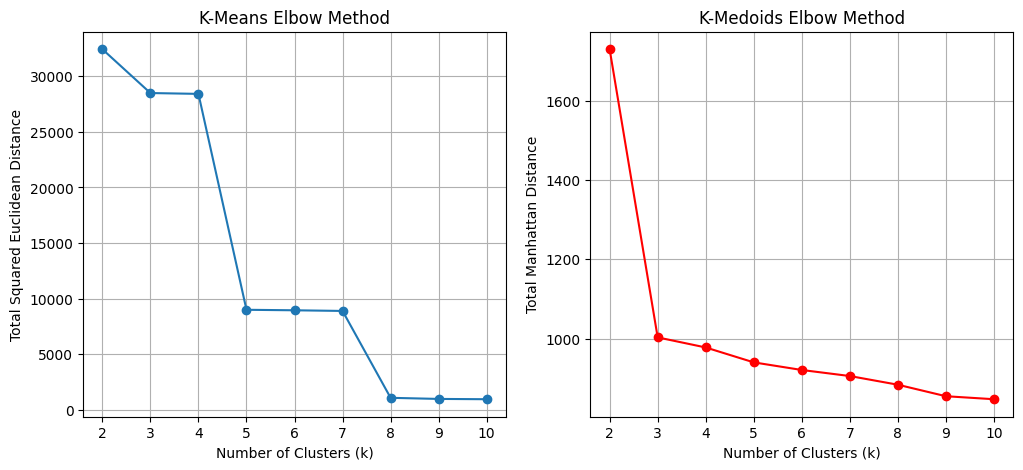

In [5]:
k_values = range(2, 11)  # k from 2 to 10
kmeans_costs = []
kmedoids_costs = []

for k in k_values:
    _, _, kmeans_cost = kmeans_lloyd(data_outliers, k)
    _, _, kmedoids_cost = kmedoids_lloyd(data_outliers, k)

    kmeans_costs.append(kmeans_cost)
    kmedoids_costs.append(kmedoids_cost)

# Plot the Elbow Graphs
plt.figure(figsize=(12, 5))

# K-Means Elbow Plot
plt.subplot(1, 2, 1)
plt.plot(k_values, kmeans_costs, marker='o', linestyle='-')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Total Squared Euclidean Distance")
plt.title("K-Means Elbow Method")
plt.grid()

# K-Medoids Elbow Plot
plt.subplot(1, 2, 2)
plt.plot(k_values, kmedoids_costs, marker='o', linestyle='-', color='r')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Total Manhattan Distance")
plt.title("K-Medoids Elbow Method")
plt.grid()

plt.show()

The elbow value of K-Means is k = 4, whereas for K-Medoids it is k = 3. The presence of outliers have influenced the k-value for k-means.

c)

In [6]:
num_runs = 20
k = 3

kmeans_costs = []
kmedoids_costs = []

for _ in range(num_runs):

    np.random.seed(_)
    shuffled_data = np.random.permutation(data_outliers)

    # Run K-Means with different random initialization
    _, _, kmeans_cost = kmeans_lloyd(shuffled_data, k)

    # Run K-Medoids with different random initialization
    _, _, kmedoids_cost = kmedoids_lloyd(shuffled_data, k)

    kmeans_costs.append(kmeans_cost)
    kmedoids_costs.append(kmedoids_cost)

# Compute variance
kmeans_variance = np.var(kmeans_costs)
kmedoids_variance = np.var(kmedoids_costs)

print(f"Variance of K-Means cost: {kmeans_variance:.4f}")
print(f"Variance of K-Medoids cost: {kmedoids_variance:.4f}")

Variance of K-Means cost: 58836362.2772
Variance of K-Medoids cost: 56682.5054


K-Medoids is less sensitive as the cluster representative is an actual datapoint, whereas K-Means uses the mean of all points in a cluster thus it is greatly affected by outliers.

Question 3

In [8]:
from google.colab import drive
drive.mount('/content/gdrive')

import pandas as pd
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression


Mounted at /content/gdrive


a)

In [9]:
# Load the data
train_data = pd.read_csv('gdrive/My Drive/2025 50.007 ML HW2/breast_cancer_dataset/train.csv')
test_data = pd.read_csv('gdrive/My Drive/2025 50.007 ML HW2/breast_cancer_dataset/test.csv')

# Separate features and target labels for training and testing datasets
X_train = train_data.iloc[:, :-1].values  # Convert to numpy array (all columns except the last one)
y_train = train_data.iloc[:, -1].values   # Target label (last column)

X_test = test_data.iloc[:, :-1].values    # Convert to numpy array (all columns except the last one)
y_test = test_data.iloc[:, -1].values     # Target label for testing data

# Standardize the features (important for SVM)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)  # Fit and transform training data
X_test = scaler.transform(X_test)        # Only transform test data

# Train SVM with different kernels and report accuracy
kernels = ['linear', 'poly', 'rbf']
accuracies = {}

for kernel in kernels:
    # Initialize the SVM classifier with the given kernel
    if kernel == 'poly':
        model = SVC(kernel=kernel, degree=10)
    elif kernel == 'rbf':
        model = SVC(kernel=kernel, gamma=0.0001)
    else:
        model = SVC(kernel=kernel)

    # Train the model
    model.fit(X_train, y_train)

    # Make predictions on the test data
    y_pred = model.predict(X_test)

    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    accuracies[kernel] = accuracy

# Print the accuracies for each kernel
for kernel, accuracy in accuracies.items():
    print(f"Accuracy with {kernel} kernel: {accuracy:.4f}")

Accuracy with linear kernel: 0.9735
Accuracy with poly kernel: 0.7611
Accuracy with rbf kernel: 0.8053


b)

In [10]:
# Train Logistic Regression model
logreg_model = LogisticRegression(max_iter=1000)  # Increase max_iter if convergence warning occurs
logreg_model.fit(X_train, y_train)

# Make predictions on the test data
logreg_pred = logreg_model.predict(X_test)

# Calculate accuracy for Logistic Regression
logreg_accuracy = accuracy_score(y_test, logreg_pred)
print(f"Accuracy with Logistic Regression: {logreg_accuracy:.4f}")


Accuracy with Logistic Regression: 0.9735


Either logistic regression or SVM with linear kernel as they achieve the highest accuracy.

Question 4


In [12]:
!pip install tensorflow numpy matplotlib scikit-learn
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles

Training: Baseline | Depth: 1, Width: 2, Activation: relu
Training: Increased Depth | Depth: 2, Width: 2, Activation: relu
Training: Increased Depth | Depth: 3, Width: 2, Activation: relu
Training: Increased Width | Depth: 1, Width: 8, Activation: relu
Training: Increased Width | Depth: 1, Width: 16, Activation: relu
Training: Activation Function | Depth: 1, Width: 2, Activation: tanh
Training: Activation Function | Depth: 1, Width: 2, Activation: sigmoid


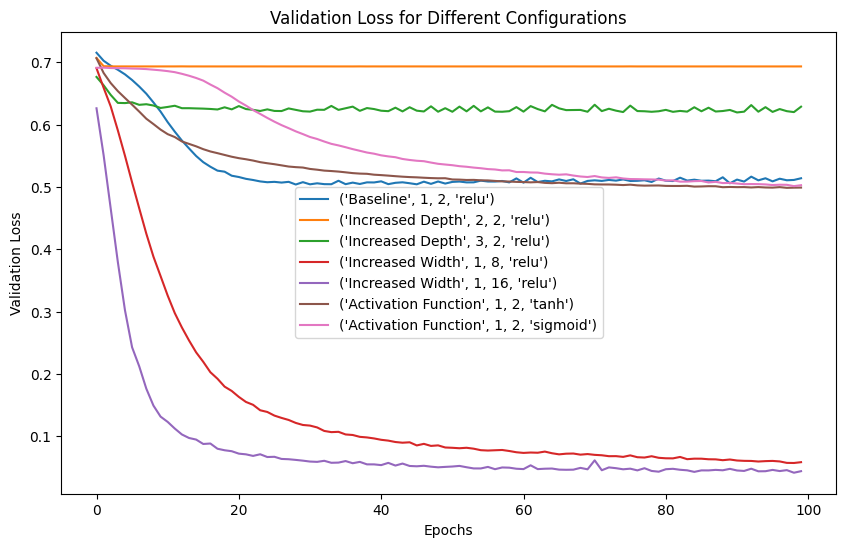

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


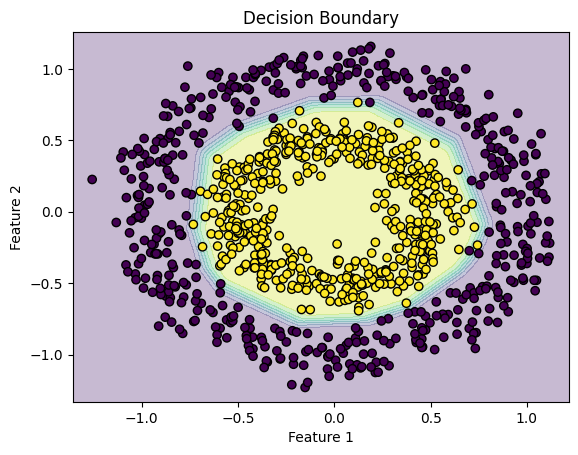

In [13]:
# Generate dataset
X, y = make_circles(n_samples=1000, noise=0.1, factor=0.5, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Function to build model
def build_model(depth=1, width=2, activation='relu', learning_rate=0.01):
    model = keras.Sequential()
    model.add(keras.layers.Input(shape=(2,)))  # Input layer

    for _ in range(depth):
        model.add(keras.layers.Dense(width, activation=activation))

    model.add(keras.layers.Dense(1, activation='sigmoid'))  # Output layer

    model.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# Experiment configurations
configs = [
    ("Baseline", 1, 2, 'relu'),
    ("Increased Depth", 2, 2, 'relu'),
    ("Increased Depth", 3, 2, 'relu'),
    ("Increased Width", 1, 8, 'relu'),
    ("Increased Width", 1, 16, 'relu'),
    ("Activation Function", 1, 2, 'tanh'),
    ("Activation Function", 1, 2, 'sigmoid')
]

# Train models and store results
results = {}

for name, depth, width, activation in configs:
    print(f"Training: {name} | Depth: {depth}, Width: {width}, Activation: {activation}")
    model = build_model(depth, width, activation)
    history = model.fit(X_train, y_train, epochs=100, verbose=0, validation_data=(X_test, y_test))
    results[(name, depth, width, activation)] = history.history

# Plot Loss Curves
plt.figure(figsize=(10, 6))
for key, history in results.items():
    plt.plot(history['val_loss'], label=f"{key}")
plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.legend()
plt.title("Validation Loss for Different Configurations")
plt.show()

# Decision Boundary Function
def plot_decision_boundary(model, X, y):
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    grid = np.c_[xx.ravel(), yy.ravel()]
    preds = model.predict(grid).reshape(xx.shape)

    plt.contourf(xx, yy, preds, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title("Decision Boundary")
    plt.show()

# Pick best model (lowest validation loss)
best_model_key = min(results, key=lambda k: min(results[k]['val_loss']))
best_model = build_model(*best_model_key[1:])
best_model.fit(X_train, y_train, epochs=100, verbose=0)
plot_decision_boundary(best_model, X, y)

a) A greater number of hidden layers, neurons and the ReLU activation function gives the best model in terms of validation loss.

b) b) The model using the ReLU activation function with 16 neurons and 1 hidden layer produces the best performance, however the extremely low validation loss might indicate possible overfitting. Hence 1 layer, 8 neurons with the ReLU activation function is the most balanced model to use.